In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
new_neurons = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/si_sorted_Zombies_dir_ols_on_single_neurons_pKW.pkl')
old_neurons = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_results/Zombies_dir_ols_on_single_neurons_only_pANOVA_significant.pkl')

new_r2 = new_neurons[new_neurons['R-squared']>0.2]
old_r2 = old_neurons[old_neurons['R-squared']>0.2]

In [37]:
new_neurons


,NeuronID,Behavior,Source_Monkey,Model,R-squared,coef,intercept,p_value,p_perm,Behavior_Vector,Design_Matrix,Neural_Response
753,ER_2023-11-22_2_Channel.C_013_Unit 1,AgonismTo,143H,ols,4.394135e-08,0.000432,5.226555,0.999607,1.000,"[0, 1, 1, 0, 1, 0, 0, 1]","[[1.0, 0.0], [1.0, 1.0], [1.0, 1.0], [1.0, 0.0...","[4.269349339051461, 6.2973440348895, 4.6314378..."
156,ER_2023-12-18_3_Channel.C_004_Unit 1,AffiliationTo,94B,ols,5.627157e-08,-0.000032,11.998354,0.999555,1.000,"[38, 43, 24, 18, 6, 26, 29, 4]","[[1.0, 38.0], [1.0, 43.0], [1.0, 24.0], [1.0, ...","[9.842244402161207, 12.16746622031528, 15.7400..."
218,AMG_2023-10-04_4_Channel.C_000_Unit 1,AffiliationFrom,72X,ols,9.523594e-08,0.000082,8.894777,0.999421,1.000,"[9, 9, 24, 8, 17, 18, 4, 0]","[[1.0, 9.0], [1.0, 9.0], [1.0, 24.0], [1.0, 8....","[12.884987524802435, 7.12167092883804, 7.97612..."
266,ER_2023-11-22_2_Channel.C_013_Unit 1,AffiliationFrom,67G,ols,1.787062e-06,0.000175,5.271914,0.997493,0.998,"[27, 13, 17, 6, 22, 17, 1, 8]","[[1.0, 27.0], [1.0, 13.0], [1.0, 17.0], [1.0, ...","[4.269349339051461, 6.2973440348895, 4.6314378..."
736,ER_2023-11-08_4_Channel.C_019_Unit 1,AgonismTo,87J,ols,2.471512e-06,-0.001341,11.477330,0.997052,0.996,"[0, 0, 0, 2, 2, 5, 3, 6]","[[1.0, 0.0], [1.0, 0.0], [1.0, 0.0], [1.0, 2.0...","[13.338451991138172, 9.606431097064577, 11.845..."
...,...,...,...,...,...,...,...,...,...,...,...,...
76,AMG_2023-10-10_2_Channel.C_015_Unit 1,AffiliationTo,110E,ols,7.380909e-01,-0.110912,13.626156,0.006272,0.006,"[90, 3, 8, 8, 22, 9, 1, 18]","[[1.0, 90.0], [1.0, 3.0], [1.0, 8.0], [1.0, 8....","[4.099221052252437, 15.323807191824685, 11.530..."
570,ER_2023-11-08_4_Channel.C_019_Unit 1,SubmissionFrom,94B,ols,7.520734e-01,-0.125674,13.506000,0.005285,0.001,"[1, 13, 10, 15, 43, 28, 8, 1]","[[1.0, 1.0], [1.0, 13.0], [1.0, 10.0], [1.0, 1...","[13.338451991138172, 9.606431097064577, 11.845..."
959,ER_2023-12-11_3_Channel.C_022_Unit 1,AgonismFrom,67G,ols,7.536888e-01,-0.594451,6.226355,0.005178,0.016,"[7, 1, 7, 5, 1, 0, 5, 4]","[[1.0, 7.0], [1.0, 1.0], [1.0, 7.0], [1.0, 5.0...","[2.2642377174227812, 4.702352038833135, 2.3947..."
558,AMG_2023-10-10_2_Channel.C_015_Unit 1,SubmissionFrom,7124,ols,7.945191e-01,-0.071102,14.205352,0.002950,0.020,"[4, 9, 7, 11, 90, 41, 16, 7]","[[1.0, 4.0], [1.0, 9.0], [1.0, 7.0], [1.0, 11....","[15.323807191824685, 11.53065975872664, 13.896..."


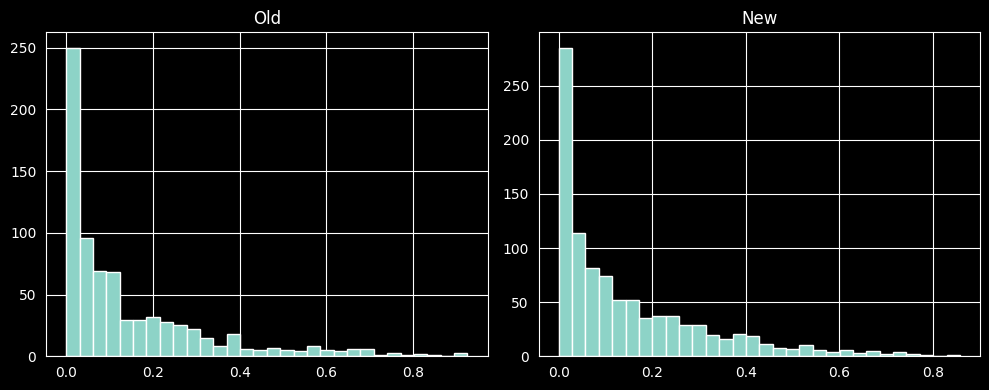

In [36]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(old_neurons['R-squared'], bins=30)
plt.title('Old')

plt.subplot(1,2,2)
plt.hist(new_neurons['R-squared'], bins=30)
plt.title('New')

plt.tight_layout()
plt.show()


In [31]:
# Is R-squared for new neurons statistically better? -- Are R-squared values in new generally larger than in old?
from scipy.stats import mannwhitneyu

u, p = mannwhitneyu(
    old_neurons['R-squared'],
    new_neurons['R-squared'],
    alternative='greater'   # new > old
)

print(f'U={u:.2f}, p={p:.4g}')

# Not necessarily better

U=353993.00, p=0.904


In [32]:
# Same question but K-S test

from scipy.stats import ks_2samp

ks, p = ks_2samp(
    new_neurons['R-squared'],
    old_neurons['R-squared']
)

print(f'KS={ks:.3f}, p={p:.4g}')
# Not better either.....

KS=0.056, p=0.139


In [34]:
# Simply comparing medians
print('Median old:', old_neurons['R-squared'].median())
print('Median new:', new_neurons['R-squared'].median())
# maybe tiny bit better


Median old: 0.07417077641042363
Median new: 0.08830806385765949
Δ median R²: 0.014137287447235858


In [35]:
# effect size
delta = new_neurons['R-squared'].median() - old_neurons['R-squared'].median()
print('Δ median R²:', delta)

Δ median R²: 0.014137287447235858


In [41]:
new_windows = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/analysis_cache/si_sorted_Zombies_significant_windows_pKW_passed.pkl')
old_windows = pd.read_pickle('/home/connorlab/Documents/GitHub/Julie/Cortana/old/old_analysis_cache/Zombies_significant_windows_pANOVAorGLM_passed.pkl')
print(new_windows.shape)
print(old_windows.shape)

(35, 7)
(631, 10)
